In [1]:
import warnings
warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from binance import Client
from secrets import binance_api_key, binance_secret_key

In [2]:
client = Client(binance_api_key, binance_secret_key)
def get_tickers():
    tickers = []
    for info in client.futures_mark_price():
        ticker = info['symbol']
        if ticker[-4:] == "USDT":
            tickers.append(info['symbol'])
    return tickers

def get_sample(ticker, start_date="1 Jan, 2021"):
    klines = np.array(client.futures_historical_klines(ticker, Client.KLINE_INTERVAL_1DAY, start_date))
    sample = pd.DataFrame(klines.reshape(-1, 12), dtype=float, columns=['datetime',
                                                                        'open', 
                                                                        'high', 
                                                                        'low', 
                                                                        'close', 
                                                                        'volume', 
                                                                        'close time', 
                                                                        'quote asset volume, number of trades', 
                                                                        'number of trades',
                                                                        'taker buy base asset volume', 
                                                                        'taker buy quote asset volume', 
                                                                        'ignore'])
    sample['datetime'] = pd.to_datetime(sample['datetime'], unit='ms')
    sample.set_index('datetime', inplace=True)
    sample = sample[['open', 'high', 'low', 'close', 'volume']].copy()
    return sample

sample = get_sample("BTCUSDT")
sample.tail()

print(len(get_tickers()))

135


In [3]:
tickers = get_tickers()
ref = get_sample("ETHUSDT", start_date="1 Jan, 2020")
pre_samples = dict()
for ticker in tickers:
    sample = get_sample(ticker, start_date="1 Jan, 2020")
    if len(sample) < 220: continue
    
    # preprocess
    sample['noise'] = 1.-abs(sample['close'] - sample['open'])/(sample['high'] - sample['low'])
    sample['noise15'] = sample['noise'].rolling(10).mean()
    sample['target_up'] = sample['open'] + sample['noise15']*(sample.shift(1)['high'] - sample.shift(1)['low'])
    sample['target_down'] = sample['open'] - sample['noise15']*(sample.shift(1)['high'] - sample.shift(1)['low'])
    sample['momentum'] = (sample['close'] - sample.shift(10)['close'])/sample.shift(10)['close']
    sample['reward_up'] = 1. + sample['close'].pct_change()
    sample['reward_down'] = 1. - sample['close'].pct_change()
    sample['log_reward_up'] = np.log(sample['reward_up'])
    sample['log_reward_down'] = np.log(sample['reward_down'])
    sample['total_reward'] = sample['reward_up'].cumprod()
    sample.dropna(inplace=True)
    
    pre_samples[ticker] = sample.copy(); del sample
pre_samples['ETHUSDT'].tail(10)

,open,high,low,close,volume,noise,noise15,target_up,target_down,momentum,reward_up,reward_down,log_reward_up,log_reward_down,total_reward
datetime,,,,,,,,,,,,,,,
2021-12-11,3895.85,4094.82,3831.01,4089.81,1729754.927,0.264774,0.543505,4085.620072,3706.079928,-0.108325,1.049759,0.950241,0.048561,-0.051040,31.310749
2021-12-12,4088.86,4173.37,3985.00,4129.00,1044691.201,0.786909,0.558173,4236.111518,3941.608482,-0.085355,1.009582,0.990418,0.009537,-0.009629,31.610779
2021-12-13,4129.16,4142.00,3668.34,3780.63,2252296.914,0.264177,0.530563,4229.102110,4029.217890,-0.102768,0.915628,1.084372,-0.088145,0.081001,28.943730
2021-12-14,3780.33,3879.13,3682.00,3856.66,1718001.410,0.612794,0.503370,4018.756383,3541.903617,-0.062960,1.020110,0.979890,0.019911,-0.020315,29.525800
2021-12-15,3856.67,4096.00,3639.39,4019.01,2415815.067,0.644467,0.505979,3956.413715,3756.926285,-0.042530,1.042096,0.957904,0.041234,-0.043008,30.768718
2021-12-16,4019.01,4118.47,3951.14,3958.67,1603846.854,0.639395,0.502193,4248.316362,3789.703638,-0.088956,0.984986,1.015014,-0.015127,0.014902,30.306768
2021-12-17,3958.70,3992.99,3694.20,3873.93,2112402.041,0.716289,0.497165,4041.890602,3875.509398,-0.100304,0.978594,1.021406,-0.021639,0.021180,29.658016
2021-12-18,3872.98,3997.39,3764.96,3957.64,1306368.673,0.635761,0.517139,4027.495828,3718.464172,-0.107701,1.021609,0.978391,0.021378,-0.021845,30.298882
2021-12-19,3957.65,4034.99,3881.89,3922.51,1402356.037,0.770477,0.573976,4091.059158,3824.240842,-0.044176,0.991123,1.008877,-0.008916,0.008837,30.029934


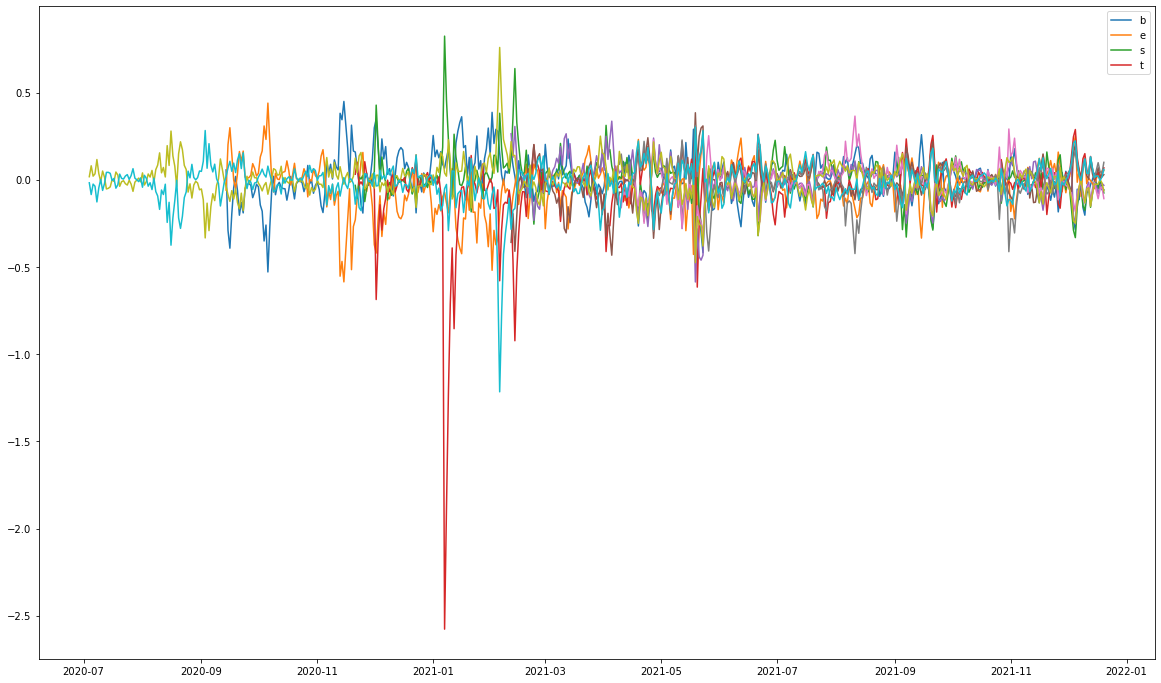

In [4]:
# make value functions
samples = dict()
for ticker in pre_samples.keys():
    sample = pre_samples[ticker].copy()
    sample['value_up'] = 0.
    sample['value_down'] = 0.
    
    for idx in sample.index:
        if idx == sample.index[0]:
            sample.loc[idx, 'value_up'] = sample.loc[idx, 'log_reward_up']
            sample.loc[idx, 'value_down'] = sample.loc[idx, 'log_reward_down']
            continue
        
        gamma = 1. - 0.5*sample.loc[idx, 'noise']
        sample.loc[idx, 'value_up'] = sample.loc[idx, 'log_reward_up'] + gamma*(sample.shift(1).loc[idx, 'value_up'])
        sample.loc[idx, 'value_down'] = sample.loc[idx, 'log_reward_down'] + gamma*(sample.shift(1).loc[idx, 'value_down'])
    samples[ticker] = sample

plt.figure(figsize=(20, 12))
for ticker in list(samples.keys())[:5]:
    plt.plot(samples[ticker].index, samples[ticker].value_up, label=f"{ticker}-up")
    plt.plot(samples[ticker].index, samples[ticker].value_down, label=f"{ticker}-down")
plt.legend('best')
plt.show()

In [5]:
book = samples['BTCUSDT'][['close']].copy()
book['number'] = book.index.map(mdates.date2num)
book['reward'] = 1.
book['value_up'] = 0.
book['value_down'] = 0.

for idx in book.index:
    if idx in [ref.index[0], ref.index[-1]]: continue
    
    # select 21 highest volume coins
    volumes = dict()
    for ticker in samples.keys():
        try:
            volumes[ticker] = samples[ticker].loc[idx, 'close']*samples[ticker].loc[idx, 'volume']
        except:
            continue
    top21v = dict(sorted(volumes.items(), key=(lambda x: x[1]), reverse=True)[:21])
    
    # select 5 up, 5 down
    values = dict()
    for ticker in samples.keys():
        try:
            values[f"{ticker}-UP"] = samples[ticker].loc[idx, 'value_up']
            values[f"{ticker}-DOWN"] = samples[ticker].loc[idx, 'value_down']
        except:
            continue
    res = dict(sorted(values.items(), key=(lambda x: x[1]), reverse=True)[:6])
    
    book.loc[idx, 'value'] = np.mean(list(res.values()))
    
    reward = 0.
    leverage = 1.
    ratio = 1/len(res)
    
    for coin in res.keys():
        if "UP" in coin:
            ticker = coin[:-3]
            if samples[ticker].loc[idx, 'momentum'] < 0.3:
                reward += ratio
            elif samples[ticker].loc[idx, 'momentum'] < 0.8:
                reward += ratio*(1.+1.*(samples[ticker].shift(-1).loc[idx, 'reward_up']-1.002))
            else:
                if samples[ticker].loc[idx, 'close']/samples[ticker].shift(-1).loc[idx, 'low'] - 1. < -1./4.:
                    reward += 0.
                else:
                    reward += ratio*(1.+4.*(samples[ticker].shift(-1).loc[idx, 'reward_up']-1.002))
        else:
            ticker = coin[:-5]
            if samples[ticker].loc[idx, 'momentum'] > -0.3:
                reward += ratio
            elif samples[ticker].loc[idx, 'momentum'] > -0.6:
                if samples[ticker].loc[idx, 'close']/samples[ticker].shift(-1).loc[idx, 'low'] - 1. < -1./2.:
                    reward += 0.
                else:
                    reward += ratio*(1.+2.*(samples[ticker].shift(-1).loc[idx, 'reward_up']-1.002))
            else:
                if samples[ticker].loc[idx, 'close']/samples[ticker].shift(-1).loc[idx, 'low'] - 1. < -1./12.:
                    reward += 0.
                else:
                    reward += ratio*(1.+12.*(samples[ticker].shift(-1).loc[idx, 'reward_up']-1.002))
    book.loc[idx, 'reward'] = reward
book.dropna(inplace=True)
book.tail(20)    

,close,number,reward,value_up,value_down,value
datetime,,,,,,
2021-11-30,56975.00,18961.0,1.011258,0.0,0.0,0.169651
2021-12-01,57209.29,18962.0,0.979033,0.0,0.0,0.219446
2021-12-02,56513.57,18963.0,0.991831,0.0,0.0,0.161357
2021-12-03,53612.00,18964.0,0.941239,0.0,0.0,0.160665
2021-12-04,49135.66,18965.0,0.930591,0.0,0.0,0.255425
2021-12-05,49376.60,18966.0,1.079331,0.0,0.0,0.303147
2021-12-06,50424.72,18967.0,1.013963,0.0,0.0,0.158289
2021-12-07,50577.20,18968.0,1.062792,0.0,0.0,0.161871
2021-12-08,50455.61,18969.0,0.956941,0.0,0.0,0.155417


==== value trading ====
Accumulated Returns: 6007763.69 %
CAGR: 28749.01 %
MDD: -70.45 %
VOL: 373.813 %
Sharpe: 10028.68 %


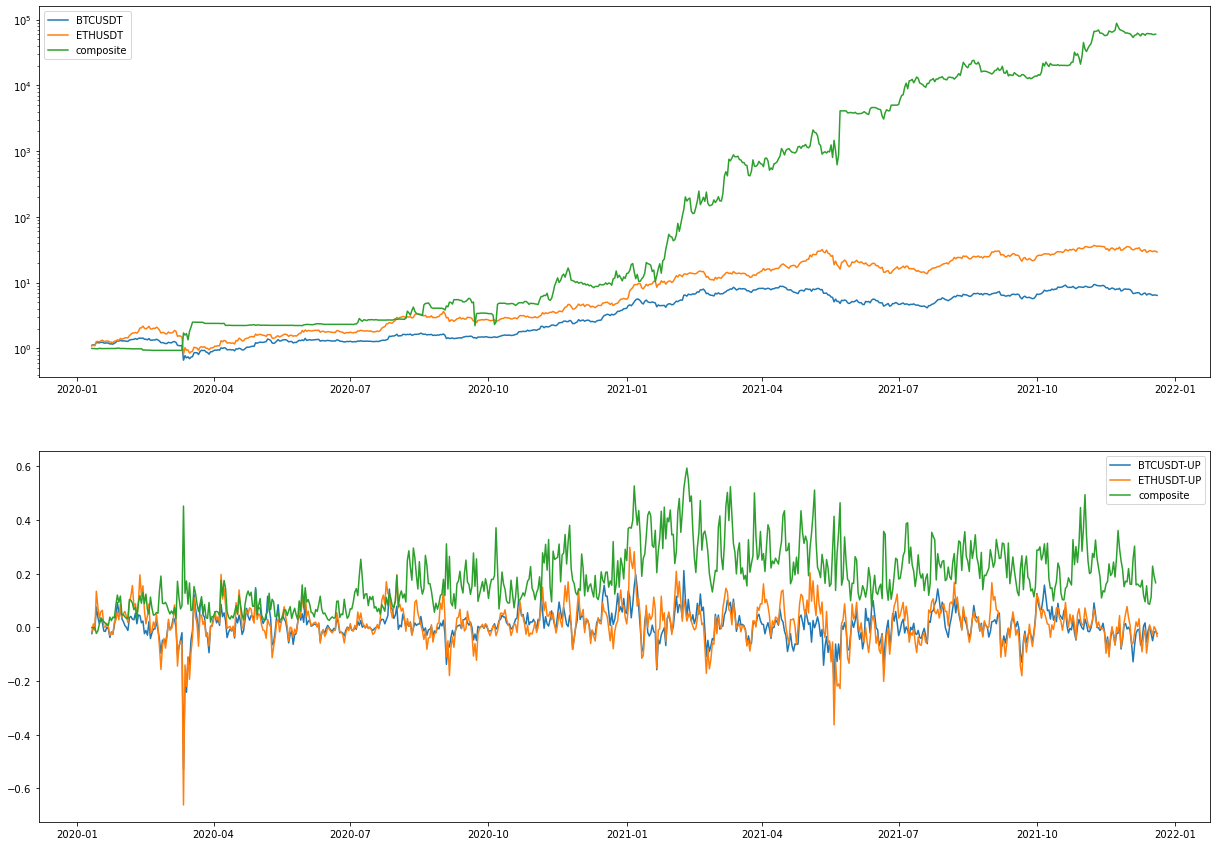

In [10]:
# evaluate
total_reward = 1.
for idx in book.index:
    total_reward *= book.loc[idx, 'reward']
    book.loc[idx, 'total_reward'] = total_reward
CAGR = book['total_reward'].iloc[-1]**(365./len(book.index)) - 1.

historical_max = book['total_reward'].cummax()
daily_drawdown = book['total_reward']/historical_max - 1.
historical_dd = daily_drawdown.cummin()
MDD = historical_dd.min()
VOL = np.std(book['reward'])*np.sqrt(365.)
Sharpe = (np.mean(book['reward'])/np.std(book['reward'])*np.sqrt(365.))

print("==== value trading ====")
print("Accumulated Returns:", round((total_reward-1.)*100, 2), "%")
print("CAGR:", round(CAGR*100, 2), "%")
print("MDD:", round(MDD*100, 2), "%")
print("VOL:", round(VOL*100, 3), "%")
print("Sharpe:", round(Sharpe*100,2), "%")

plt.figure(figsize=(21, 15))
plt.subplot(2, 1, 1)
plt.yscale('log')
plt.plot(samples['BTCUSDT'].index, samples['BTCUSDT'].total_reward, label="BTCUSDT")
plt.plot(samples['ETHUSDT'].index, samples['ETHUSDT'].total_reward, label="ETHUSDT")
plt.plot(book.index, book.total_reward, label='composite')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.plot(samples['BTCUSDT'].index, samples['BTCUSDT'].value_up, label="BTCUSDT-UP")
plt.plot(samples['ETHUSDT'].index, samples['ETHUSDT'].value_up, label="ETHUSDT-UP")
plt.plot(book.index, book.value, label="composite")
plt.legend(loc='best')

plt.show()